# Chapter 9: What a Radiomics Feature Actually Is

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter09_Radiomics_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 13 extracted 1130 numbers per patient and fed them to a model. It never said what any of them
were. This chapter opens the box.

That matters for a practical reason. Chapter 13 ended on the observation that geometric methods
reproduce better than fitted models. By the end of this chapter you will be able to say something
sharper: **which features reproduce, and which ones you should expect to move when somebody else
runs your pipeline.**

You will be able to:

1. Name the three families of radiomics features and say what each measures.
2. Use a **pattern** to pin down a feature set instead of taking whatever the defaults give.
3. Call the extraction primitives directly, and check image and mask geometry before trusting either.
4. Measure how much one preprocessing choice — the gray-level bin width — moves each feature.
5. Explain why that choice devastates texture features and leaves shape features untouched.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", os.getcwd())

Running on Colab: False
Working directory: /home/wxc151/projects/Biomedical-Image-Analysis-in-Python


In [2]:
import subprocess
import sys

# rt-utils converts the tumor contours, and it pulls in OpenCV. The ordinary
# OpenCV build needs a graphics library that servers and containers lack, so
# without the headless build every contour conversion dies on libGL.so.1 —
# an error that looks nothing like its cause.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "qradiomics", "rt-utils", "opencv-python-headless"], check=True)

CompletedProcess(args=['/home/wxc151/.pyenv/versions/miniconda3-latest/bin/python', '-m', 'pip', 'install', '-q', 'qradiomics', 'rt-utils', 'opencv-python-headless'], returncode=0)

In [3]:
import pathlib
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import medimage_data as md

# Prepares the cohort on first call and caches it; later chapters reuse the
# same artifacts, so the notebooks have no ordering dependency between them.
paths = md.fetch_lung1_cohort(60)
WORK = paths["work"]
manifest = paths["cropped"] / "manifest.csv"

print()
print(pd.read_csv(manifest).head(3).to_string(index=False))

Lung1 cohort ready: 59 patients, 1130 features in work/lung1
Source: Aerts HJWL, Wee L, Rios Velazquez E, et al. (2019). Data From NSCLC-Radiomics. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2015.PF0M9REI  (CC BY-NC 3.0)

patient_id modality                                       image_path                                               mask_path
 LUNG1-003       CT work/lung1/cropped/LUNG1-003_cropped-1mm_CT.nrrd work/lung1/cropped/LUNG1-003_cropped-1mm_GTV-label.nrrd
 LUNG1-002       CT work/lung1/cropped/LUNG1-002_cropped-1mm_CT.nrrd work/lung1/cropped/LUNG1-002_cropped-1mm_GTV-label.nrrd
 LUNG1-004       CT work/lung1/cropped/LUNG1-004_cropped-1mm_CT.nrrd work/lung1/cropped/LUNG1-004_cropped-1mm_GTV-label.nrrd


## 1. Three families

Every radiomics feature is a number computed from an image and a mask. They fall into three groups,
and the groups behave very differently.

**Shape.** Volume, surface area, elongation, sphericity. Computed from the *mask alone* — the image
is not consulted. A tumor's volume does not depend on how you display the CT.

**First-order.** Mean, median, skewness, entropy of the pixel values inside the mask. Computed from
the *histogram*, ignoring where each pixel sits. Two tumors with identical histograms have identical
first-order features even if one is striped and the other is spotted.

**Texture.** This is where the spatial arrangement enters. These features count how often pairs or
runs of gray levels occur next to each other — how often a bright pixel neighbors a dark one, how
long uniform runs are, how many distinct zones there are. The families are known by their acronyms:

| Family | Counts |
|---|---|
| GLCM | pairs of neighboring gray levels |
| GLRLM | runs of consecutive equal gray levels |
| GLSZM | connected zones of equal gray level |
| GLDM | dependence of a pixel on its neighborhood |
| NGTDM | difference between a pixel and its surroundings |

Texture features are where the promise of radiomics lives — the claim that they see heterogeneity a
radiologist cannot. They are also, as we are about to measure, the fragile ones.

## 2. Patterns: pinning down what gets computed

Left to its own devices, an extractor computes whatever its defaults say, and defaults change
between versions. A **pattern** is a named, versioned specification of exactly which image
transforms and feature classes to compute — so the same pattern name gives the same feature set on
someone else's machine next year.

In [4]:
print(subprocess.run(["qr", "pattern", "list"], capture_output=True, text=True).stdout)

Found 4 pattern template(s):

1. ct-default  (CT Default Radiomics)
   Version: 1.0
   Tags:    ct, general, multi-type

2. nsclc-survival  (NSCLC CT Survival Radiomics)
   Version: 1.0
   Tags:    nsclc, lung, ct, survival, gtv, single-timepoint

3. standard-radiomics  (Standard Radiomics Analysis)
   Version: 1.0
   Tags:    general, classification, regression, single-timepoint

4. survival-analysis  (Radiomics Survival Analysis)
   Version: 1.0
   Tags:    survival, time-to-event, cox, oncology, prognosis




Chapter 13 used `nsclc-survival`, which applies wavelet, Laplacian-of-Gaussian, square, square-root
and logarithm transforms on top of the original image, giving about 1130 features. Running with no
pattern at all gives the plain feature set on the original image only — 107 features.

The difference is not subtle, and neither number is more correct than the other. What matters is
that it is **written down**.

## 3. The primitives underneath

`qr extract` is a wrapper. Underneath is `qradiomics.atomic`, which you can call directly when you
want one image rather than a cohort.

The step worth knowing about is `check_geometry`. An image and its mask must occupy the same
physical space — same origin, same spacing, same direction. If they do not, the extractor will
happily compute features from a mask that is offset from the anatomy it is supposed to mark, and
nothing in the output will look wrong.

In [5]:
from qradiomics.atomic import check_geometry, extract_features, load_image_and_mask

row = pd.read_csv(manifest).iloc[0]
image, mask = load_image_and_mask(row.image_path, row.mask_path)

print(f"patient       {row.patient_id}")
print(f"image size    {image.GetSize()}")
print(f"image spacing {tuple(round(v, 3) for v in image.GetSpacing())}")
print(f"mask size     {mask.GetSize()}")
print()
try:
    check_geometry(image, mask)
    print("geometry check: image and mask share the same physical frame")
except Exception as exc:
    print("geometry check FAILED:", exc)

patient       LUNG1-003
image size    (56, 84, 57)
image spacing (1.0, 1.0, 1.0)
mask size     (56, 84, 57)

geometry check: image and mask share the same physical frame


In [6]:
features = extract_features(image, mask)
numeric = {k: v for k, v in features.items() if isinstance(v, (int, float, np.floating))}

groups = {}
for name in numeric:
    match = re.search(r"_(shape|firstorder|glcm|glrlm|glszm|gldm|ngtdm)_", name)
    if match:
        groups.setdefault(match.group(1), []).append(name)

print(f"{len(numeric)} numeric features from one image/mask pair\n")
for family, names in sorted(groups.items(), key=lambda kv: -len(kv[1])):
    print(f"  {family:12s} {len(names):3d}   e.g. {names[0].split('_', 2)[-1]}")

parameter force2D must be set to True to enable shape2D extraction


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


Calculating Local Binary Pattern in 2D, but extracting features in 3D. Use with caution!


...

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


1409 numeric features from one image/mask pair

  glcm         360   e.g. Autocorrelation
  firstorder   270   e.g. 10Percentile
  glrlm        240   e.g. GrayLevelNonUniformity
  glszm        240   e.g. GrayLevelNonUniformity
  gldm         210   e.g. DependenceEntropy
  ngtdm         75   e.g. Busyness
  shape         14   e.g. Elongation


## 4. The bin width problem

Here is the choice that decides how reproducible your study is, and it is usually made by accident.

Texture features count how often gray levels occur next to each other. But CT has thousands of
distinct values, so almost no two neighboring pixels share one exactly — the counts would all be
zero or one and carry no information. So before computing texture, the values are **binned** into a
smaller number of discrete levels.

The bin width sets how coarse that grouping is. A width of 25 HU puts everything from 0 to 25 into
one level. A width of 10 splits the same range into three.

That single number changes what "neighboring gray levels" means, and therefore every texture
feature. Let us measure by how much.

In [7]:
extra = {}
for width in (10, 25, 50):
    out = WORK / f"features_bw{width}.csv"
    if not out.exists():
        subprocess.run(["qr", "extract", "-m", str(manifest), "-o", str(out),
                        "--bin-width", str(width), "-j", "4"], check=True,
                       capture_output=True)
    extra[width] = pd.read_csv(out).set_index("patient_id")

reference = extra[25]
shared = [c for c in reference.columns
          if c in extra[10].columns and pd.api.types.is_numeric_dtype(reference[c])]

print(f"{len(shared)} features compared, {len(reference)} patients")
print(f"\n{'bin width':>10}{'median change vs 25':>22}{'moved >10%':>13}")
for width in (10, 50):
    change = ((extra[width][shared] - reference[shared]).abs()
              / reference[shared].abs().replace(0, np.nan)).median()
    print(f"{width:>10}{change.median():>21.1%}{(change > 0.10).mean():>13.0%}")

107 features compared, 59 patients

 bin width   median change vs 25   moved >10%
        10                40.9%          64%
        50                32.7%          63%


Roughly two thirds of the features move by more than 10% when the bin width changes from 25 to 10.
Nothing about the patient changed. Nothing about the image changed. One preprocessing constant
changed.

Now split that by feature family.

In [8]:
change = ((extra[10][shared] - reference[shared]).abs()
          / reference[shared].abs().replace(0, np.nan)).median()

by_family = {}
for name in shared:
    match = re.search(r"_(shape|firstorder|glcm|glrlm|glszm|gldm|ngtdm)_", name)
    if match:
        by_family.setdefault(match.group(1), []).append(change[name])

rows = sorted(by_family.items(), key=lambda kv: -np.nanmedian(kv[1]))

print(f"{'family':<12}{'median change':>15}{'features':>10}")
for family, values in rows:
    print(f"{family:<12}{np.nanmedian(values):>14.1%}{len(values):>10}")

family        median change  features
ngtdm               157.9%         5
gldm                 88.2%        14
glszm                84.9%        16
glrlm                63.7%        16
glcm                 60.8%        24
shape                 0.0%        14
firstorder            0.0%        18


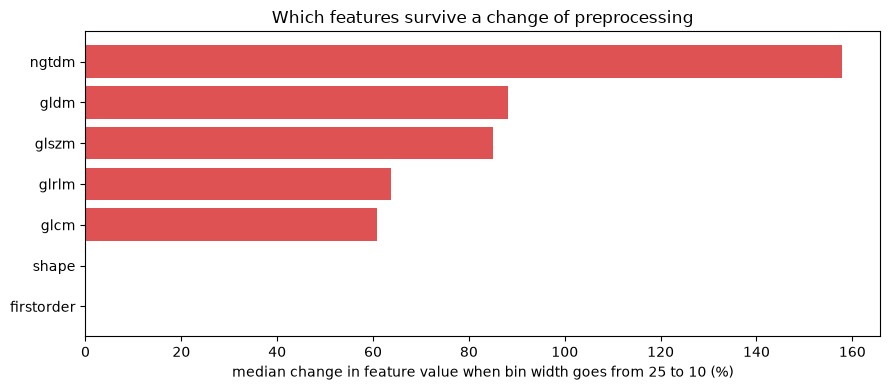

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
names = [r[0] for r in rows]
values = [np.nanmedian(r[1]) for r in rows]
colors = ["tab:red" if v > 0.01 else "tab:green" for v in values]
ax.barh(names[::-1], [v * 100 for v in values][::-1], color=colors[::-1], alpha=0.8)
ax.set_xlabel("median change in feature value when bin width goes from 25 to 10 (%)")
ax.set_title("Which features survive a change of preprocessing")
plt.tight_layout()
plt.show()

### Read that chart carefully

**Shape and first-order features do not move at all.** Not "move a little" — the median change is
exactly zero. Shape is computed from the mask, which binning never touches. First-order features are
computed from the raw values, before discretization.

**Every texture family moves enormously.** NGTDM more than doubles. GLSZM, GLDM and GLRLM shift by
60–90%.

This is not a bug in the software. It is what the features *are*: texture features are defined on a
discretized image, so a different discretization is a different feature. The number is meaningless
without the bin width attached to it.

And it explains the pattern Chapter 13 found. The spiculation features reproduced almost exactly
across independent implementations because they are geometric — they count spikes on a surface,
and no preprocessing constant sits between the mask and the answer. Texture-based signatures
reproduce worse because everyone's pipeline discretizes slightly differently.

## 5. Two engines, same image

A second source of drift: different software computes nominally the same feature differently.
`qr extract` can run more than one engine and label the columns by origin, so you can compare.

In [10]:
sample = pd.read_csv(manifest).head(6)
sample_manifest = WORK / "sample_manifest.csv"
sample.to_csv(sample_manifest, index=False)

both_csv = WORK / "features_two_engines.csv"
if not both_csv.exists():
    subprocess.run(["qr", "extract", "-m", str(sample_manifest), "-o", str(both_csv),
                    "--engine", "pyradiomics,pysera", "-j", "2"], check=True,
                   capture_output=True)

both = pd.read_csv(both_csv)
prefixes = {}
for column in both.columns:
    prefixes[column.split("_")[0]] = prefixes.get(column.split("_")[0], 0) + 1

print(f"table shape: {both.shape}")
for prefix, count in sorted(prefixes.items(), key=lambda kv: -kv[1]):
    print(f"  {prefix:14s} {count:4d} columns")

table shape: (12, 319)
  pysera          211 columns
  pyradiomics     107 columns
  patient           1 columns


Two engines, two different counts, and column names prefixed by which produced them. They overlap in
what they claim to measure but not in how much of it they compute or in the exact definitions used.

This is the problem the **IBSI** — the Image Biomarker Standardisation Initiative — exists to solve.
It publishes reference definitions and a digital phantom with known correct answers, so software can
be checked rather than assumed compatible. When a paper says its features are "IBSI-compliant", that
is the claim being made.

## 6. What to actually do

The practical guidance is short:

1. **Fix a pattern and name it in your methods.** `nsclc-survival`, not "PyRadiomics defaults".
2. **Report the bin width.** A texture feature value without one cannot be compared to anyone else's.
3. **Resample to a fixed voxel size first** — Chapter 13's `qr preprocess` step. Texture is computed
   over voxel neighborhoods, so different voxel sizes mean different neighborhoods.
4. **Prefer shape features when you can afford to.** They are immune to all three of the above and,
   as Chapter 13 showed, they reproduce.
5. **Check geometry before extracting.** A silently misaligned mask produces confident nonsense.

## Exercises

1. Extract with bin widths 5, 15, 25, 35 and 50, and plot one GLCM feature against bin width for a
   few patients. Is the relationship smooth, or does the ranking of patients change?
2. Re-run Chapter 13's survival model on the bin-width-10 features. Does the c-index move? Is the
   direction consistent, or is it noise?
3. Take one patient's mask and shift it by five voxels with `scipy.ndimage.shift`. Which features
   change most — shape, first-order or texture? Would `check_geometry` have caught it?
4. Compare a first-order feature computed by both engines on the same patient. If they disagree,
   which definition is each using?

## References

- van Griethuysen JJM, Fedorov A, Parmar C, et al. *Computational radiomics system to decode the
  radiographic phenotype.* Cancer Research. 2017;77(21):e104–e107.
- Zwanenburg A, Vallières M, Abdalah MA, et al. *The Image Biomarker Standardization Initiative:
  standardized quantitative radiomics for high-throughput image-based phenotyping.* Radiology.
  2020;295(2):328–338.
- Shafiq-ul-Hassan M, Zhang GG, Latifi K, et al. *Intrinsic dependencies of CT radiomic features on
  voxel size and number of gray levels.* Medical Physics. 2017;44(3):1050–1062.